In [4]:
import pandas as pd 
import numpy as np

In [5]:
df = pd.read_csv('heart_disease_dataset,,,csv.csv')

In [6]:
df.tail()
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


In [7]:
X = df.drop("Heart Disease",axis = 1)
y = df["Heart Disease"]

In [8]:
numerical_features = X.select_dtypes(include=["int64","float64"]).columns
categorical_features = X.select_dtypes(include = "str").columns

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

preprocessor = ColumnTransformer(
    transformers = [
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)
    ],
    remainder="passthrough"
)

In [10]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    stratify=y,
    random_state = 42,
    test_size=0.20
)

In [11]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [12]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

tree.fit(X_train_scaled,y_train)


y_pred = tree.predict(X_test_scaled)

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\n Confusion Matrix:")
cm = confusion_matrix(y_test,y_pred)
print(cm)

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       122
           1       1.00      1.00      1.00        78

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


 Confusion Matrix:
[[122   0]
 [  0  78]]


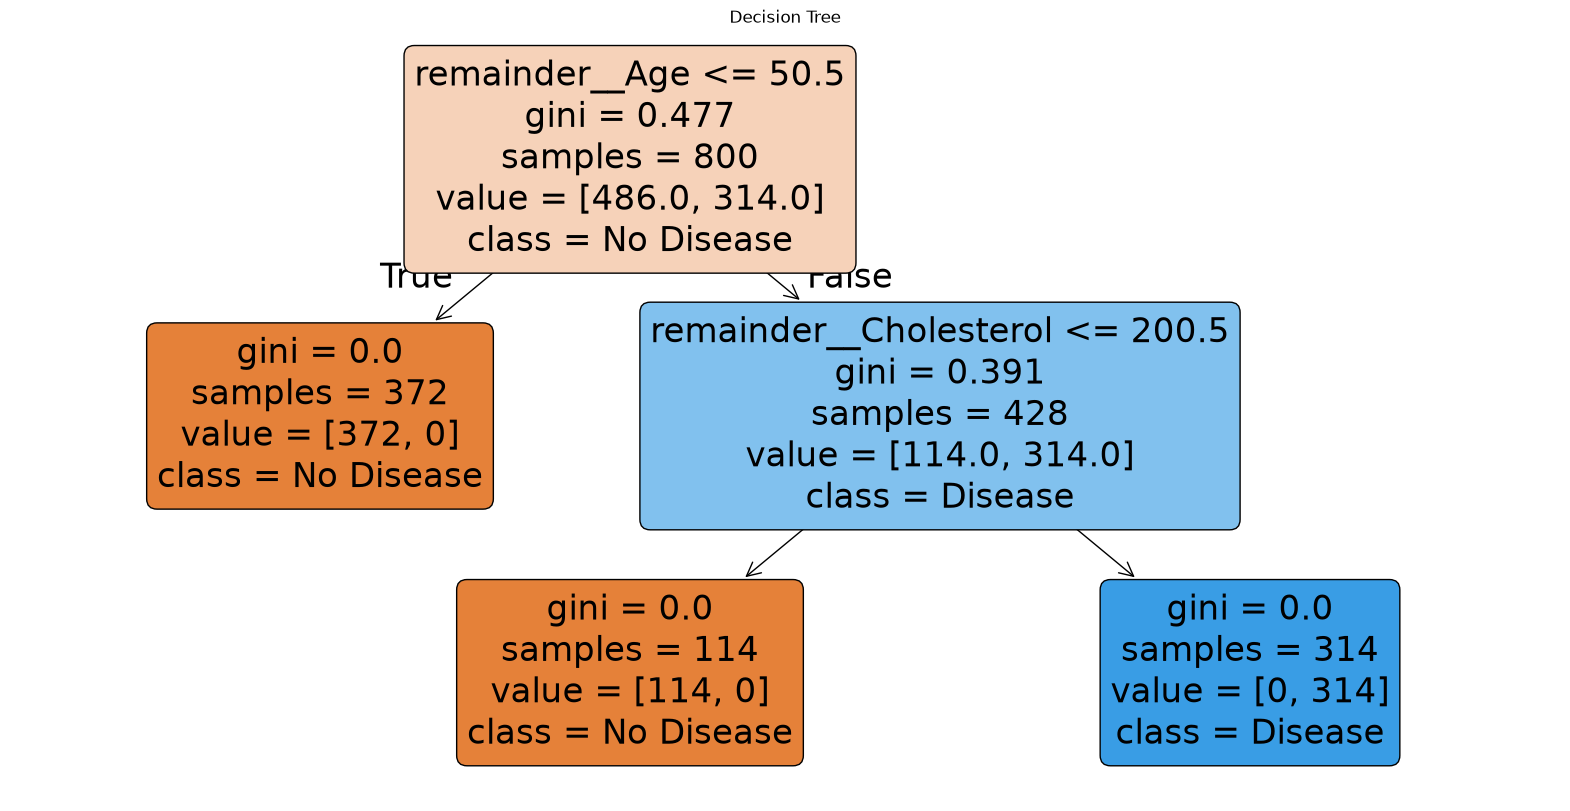

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree


plt.figure(figsize=(20, 10))

plot_tree(
    tree,
    filled=True,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=["No Disease", "Disease"],
    rounded=True
)

plt.title("Decision Tree")
plt.show()